This is a first experiment dealing with IBNRs.

Given the (apparent) lack of open source data, I decided to randomly produce reported claim tables, having as inspiration (mostly to adjust parameters) the second chapter of Greg Taylor's Loss Reserving: An Actuarial Perspective.

I begin with the description of the model generating total claims in an occurrence period. First, a parameter $\lambda\geq 0$ is selected from an inputed distribution with certain parameters, for example, a normal distribution (modified with np.clip to ensure a positive output) with loc $\mu$ and scale $\sigma$. Then, the total amount of claims $X$ is selected from a Poisson distribution with parameter $\lambda$. That is, this choice of modelling incorporates randomness to the rate parameter of the Poisson distribution yielding the total amount of claims occuring in a period.

In the case of multiple periods (which is the standard), the same procedure takes place several times from the start, i.e., a different $\lambda$ is likely to be selected at each occurrence period. On one hand, this means that different periods are likely to be somewhat different. On the other hand, this is done in a symmetrically random manner, i.e., the underlying hypothesis is that randomness arises from parameters which are external to the object of claims themselves. For example, this model does not take into account the introduction of technical improvement which diminish risk, because this is not symmetric in time. The fix (which I leave to the future) is changing the first step to an array of distributions taking the lack of symmetry in time into account.

Having the total number of claims which occurred in a period, I now describe the model generating reported claim amounts. This is done with two arrays reporting_pattern and reporting_pattern_spread.
Assume that $N_i$ claims occurred in period $i$. How many claims will be reported at period $i+j$? Select a probability $$p_j=\mathrm{reporting\_pattern}[j]\cdot P_j,$$ where $P_j$ is a normal random variable with $\mathrm{loc}=1$ and $\mathrm{scale}=\mathrm{reporting\_pattern\_spread}[j]$. Clip it to ensure that it lies between $0$ and $1$. Assume that $(N_{i,0},...,N_{i,j-1})$ is the array describing the amount of claims, which occurred at period $i$ and were reported at periods $i+0, i+1,..., i+j-1$. Thus, the number of remaining claims is given by $$\tilde{N}_j=N_i-\sum_{k=0}^{j-1}N_{i,k}.$$ Finally, the amount of claims, which occurred at period $i$ and were reported at period $i+j$, satisfies $N_i\sim \mathrm{Binom}(\tilde{N}_j, p_j)$. It is certainly reasonable to argue that a different probability $p_j$ should be selected for each of the remaining claims, which I shall implement in a future version.

A technical feature: the table containing reported data is first populated with np.nan and then with $N_{i,k}$. Therefore, data pertaining to the future is np.nan, not $0$.

In the simulations I selected $\lambda$ with a normal distribution. Thus, values used for $\mu$, $\sigma$, reporting_pattern and reporting_pattern_spread were adjusted to fit real data. One should only note that $$E(X)=E(\lambda)\textrm{ and }Var(X) = Var(\lambda)+E(\lambda).$$

Regarding the estimations of IBNR, as of yet, I have simply implemented the methods: means and the usual chain-ladder. I note that these methods can take values which give different weights to different experience periods $k=i+j$. This is an important future feature, which allows the estimation methods to deal with time assymetry.

In [6]:
import numpy as np
import pandas as pd

# Lambda sampler functions.

def lognormal_lambda_sampler(
    rng,
    mean,
    sigma,
    *,
    size=()
):
    return rng.lognormal(mean=mean, sigma=sigma, size=size)

def normal_lambda_sampler(
    rng,
    loc,
    scale,
    *,
    size=()
):
    lam = rng.normal(loc=loc, scale=scale, size=size)
    return np.clip(lam, 0.0, None)

# Introducing stochastic elements to the reporting pattern.

def noisy_hazard(
    rng,
    base_p,
    *,
    rel_scale=0.1,
    min_scale=0.01
):
    scale = max(rel_scale * base_p, min_scale)
    return np.clip(rng.normal(loc=base_p, scale=scale), 0.0, 1.0)

# Useful function to adjust numeric arrays to correct sizes.

def fix_num_array(
    num_array,
    *,
    size=(),
    fill_with_last = False,
    fill_with_mean = False
):
    num_array = np.asarray(num_array, dtype=float)
    if num_array.ndim != 1:
        raise ValueError("num_array must be a 1D array.")
    if len(size) == 0:
        return num_array

    out_length = size[0]
    if out_length <= len(num_array):
        return num_array[:out_length]

    if fill_with_last:
        if fill_with_mean:
            raise ValueError("You cannot choose to fill missing entries with the last element and the mean at the same time.")
        modified = np.full(out_length, num_array[-1], dtype=float)
        modified[:len(num_array)] = num_array
        return modified

    if fill_with_mean:
        avg = np.average(num_array)
        modified = np.full(out_length, avg, dtype=float)
        modified[:len(num_array)] = num_array
        return modified

    out = np.zeros(out_length, dtype=float)
    out[:len(num_array)] = num_array
    return out

# Model generating the total amount of claim occurring in each period.

def total_claim_number_model(
    rng,
    *,
    lambda_sampler,
    size=(),
    **sampler_kwargs
):
    lam = np.asarray(
        lambda_sampler(rng=rng, size=size, **sampler_kwargs),
        dtype = float
    )
    if np.any(lam < 0):
        raise ValueError("Poisson intensities must be nonnegative.")
    claims = rng.poisson(lam=lam)
    return claims

# Function adjusting reporting parameters.

def adj_reporting_parameters(
    reporting_pattern,
    *,
    reporting_pattern_spread=None,
    spread_fill_with_last=True
):
    reporting_pattern = np.asarray(reporting_pattern, dtype=float)
    if reporting_pattern.ndim != 1:
        raise ValueError("reporting_pattern must be a 1D array.")
    if np.any(reporting_pattern < 0) or np.any(reporting_pattern > 1):
        raise ValueError("reporting probabilities must lie in [0,1].")

    if reporting_pattern_spread is None:
        reporting_pattern_spread = np.full_like(reporting_pattern, 0.1)
    else:
        reporting_pattern_spread = np.asarray(reporting_pattern_spread, dtype=float)
        if reporting_pattern_spread.ndim != 1:
            raise ValueError("reporting_pattern_spread must be a 1D array.")
        if not spread_fill_with_last:
            if len(reporting_pattern) != len(reporting_pattern_spread):
                raise ValueError("reporting_pattern_spread must have the same length as reporting_pattern.")
        else:
            reporting_pattern_spread = fix_num_array(reporting_pattern_spread,
                                                     size=(len(reporting_pattern),),
                                                     fill_with_last=True)
    return reporting_pattern, reporting_pattern_spread

# Model generating a table of reported claims.

def reported_claims_model(
    rng,
    occurrence_periods,
    *,
    reporting_pattern,
    reporting_pattern_spread=None,
    spread_fill_with_last=True,
    lambda_sampler,
    sampler_kwargs = None
):
    sampler_kwargs = sampler_kwargs or {}

    reporting_pattern, reporting_pattern_spread = adj_reporting_parameters(
        reporting_pattern=reporting_pattern,
        reporting_pattern_spread=reporting_pattern_spread,
        spread_fill_with_last=spread_fill_with_last
    )

    ultimate_counts = total_claim_number_model(rng,
                                               lambda_sampler=lambda_sampler,
                                               size=occurrence_periods,
                                               **sampler_kwargs
    )

    row_amount, col_amount = occurrence_periods, occurrence_periods
    reported_incremental = np.full((row_amount, col_amount), np.nan)
    remaining = ultimate_counts.copy()

    for i in range(row_amount):
        obs_columns = col_amount - i
        for j in range(obs_columns):
            if j>=len(reporting_pattern):
                prob = noisy_hazard(rng,
                                    reporting_pattern[-1],
                                    rel_scale=reporting_pattern_spread[-1])
            else:
                prob = noisy_hazard(rng,
                                    reporting_pattern[j],
                                    rel_scale=reporting_pattern_spread[j])
            reported_incremental[i,j] = rng.binomial(remaining[i], prob)
            remaining[i] -= reported_incremental[i,j]

    return ultimate_counts, reported_incremental

# Assume that an array weights is given which describes the relative importance
# of data with respect to *experience period*. This function extrapolates the
# remaining entries of the triangular table with weighted averages.

def apply_wgts_triang(
    triangle,
    *,
    weights = None,
    fill_with_last = False,
    fill_with_mean = False
):
    triangle = np.asarray(triangle, dtype=float, copy=True)
    if triangle.ndim != 2:
        raise ValueError("triangle must be a 2D array.")
    row_amount, col_amount = triangle.shape

    if weights is None:
        weights = np.ones(row_amount, dtype=float)
    else:
        weights =  fix_num_array(
            weights,
            size=(row_amount,),
            fill_with_last=fill_with_last,
            fill_with_mean=fill_with_mean
        )

    if any(weight < 0 for weight in weights):
        raise ValueError("Weights must be non-negative.")

    for j in range(col_amount):
        obs_rows = row_amount - j
        if obs_rows <= 0:
            continue
        temp_weights = np.flip(weights[:obs_rows])
        triangle[obs_rows:row_amount, j] = np.average(
            triangle[:obs_rows, j],
            weights=temp_weights
        )

    return triangle

# This function returns the last observed cumulative for each occurrence period.
# It assumes that the observed data are triangular. There is also another
# possible entry most_rec_index, which describes the final observed column index
# in the last row.

def latest_obs_cumul(
    cumulative,
    most_rec_index=0
):
    cumulative = np.asarray(cumulative, dtype=float)
    if cumulative.ndim != 2:
        raise ValueError("cumulative must be a 2D array.")
    row_amount, col_amount = cumulative.shape

    latest_observed_cumulative = np.zeros(row_amount, dtype=float)
    for i in range(row_amount):
        temp_index = most_rec_index + row_amount - 1 - i
        if temp_index >= col_amount - 1:
            latest_observed_cumulative[i] = cumulative[i, -1]
        else:
            latest_observed_cumulative[i] = cumulative[i, temp_index]

    return latest_observed_cumulative

# This function returns the incremental reported data (without np.nan) given
# a cumulative table of claims.

def cumulative_to_incremental(
    cumulative
):
    cumulative = np.asarray(cumulative, dtype=float)
    if cumulative.ndim != 2:
        raise ValueError("cumulative must be a 2D array.")
    row_amount, col_amount = cumulative.shape

    incremental = np.full_like(cumulative, np.nan)
    incremental[:,0] = cumulative[:, 0]
    for j in range(1, col_amount):
        incremental[:, j] = cumulative[:, j] - cumulative[:, j - 1]

    return incremental

# This function produces the development factor of the chain-ladder method.
# It can also take a weights parameters describing  the relative importance
# of data with respect to *experience period*.

def dev_factors(
    triangle,
    *,
    weights = None,
    fill_with_last = False,
    fill_with_mean = False
):
    triangle = np.asarray(triangle, dtype=float, copy=True)
    if triangle.ndim != 2:
        raise ValueError("reported_incremental must be a 2D array.")
    row_amount, col_amount = triangle.shape

    if weights is None:
        weights = np.ones(row_amount, dtype=float)
    else:
        weights =  fix_num_array(
            weights,
            size=(row_amount,),
            fill_with_last=fill_with_last,
            fill_with_mean=fill_with_mean
        )

    development_factors = np.ones(col_amount - 1, dtype=float)
    for j in range(col_amount - 1):
        obs_rows = row_amount - (j+1)

        temp_weights = np.flip(weights[:obs_rows])
        numerator = np.average(triangle[:obs_rows, j + 1], weights=temp_weights)
        denominator = np.average(triangle[:obs_rows, j], weights=temp_weights)
        if denominator <= 0:
            raise ValueError(f"Development factor at column {j} cannot be estimated because the denominator is not positive.")
        development_factors[j] = numerator / denominator

    return development_factors

# This function extrapolates the remaining entries of a triangular table
# with development factors.

def apply_devf_triang(
    triangle,
    *,
    development_factors
):
    triangle = np.asarray(triangle, dtype=float, copy=True)
    if triangle.ndim != 2:
        raise ValueError("triangle must be a 2D array.")
    row_amount, col_amount = triangle.shape

    development_factors = np.asarray(development_factors, dtype=float)
    if development_factors.ndim != 1:
        raise ValueError("development_factors must be a 1D array.")
    if len(development_factors) != col_amount - 1:
        raise ValueError(f"development_factors must have length {col_amount - 1}.")
    if any(factor<=0 for factor in development_factors):
        raise ValueError("Development factors must be positive.")

    i_0 = np.maximum(0, row_amount-col_amount)
    for i in range(i_0, row_amount):
        last_obs_dev = col_amount - i - 1
        if last_obs_dev < 0:
            continue
        for j in range(last_obs_dev + 1, col_amount):
            triangle[i, j] = triangle[i, j - 1] * development_factors[j - 1]

    return triangle

# This function estimates total claim count with means.

def est_ibnr_count_by_mean(
    reported_incremental,
    *,
    details = False,
    weights=None,
    fill_with_last=False,
    fill_with_mean=False
):
    reported_incremental = np.asarray(reported_incremental, dtype=float)
    if reported_incremental.ndim != 2:
        raise ValueError("reported_incremental must be a 2D array.")
    row_amount, col_amount = reported_incremental.shape

    cumulative = reported_incremental.cumsum(axis=1)

    projected_incremental = apply_wgts_triang(
        triangle=reported_incremental,
        weights=weights,
        fill_with_last=fill_with_last,
        fill_with_mean=fill_with_mean
    )

    latest_observed_cumulative = latest_obs_cumul(cumulative)
    projected_cumulative = projected_incremental.cumsum(axis=1)
    ultimate_counts = projected_cumulative[:, -1]

    if details:
        remaining_estimated_ibnr = ultimate_counts - latest_observed_cumulative
        projected_incremental = pd.DataFrame(projected_incremental)
        projected_incremental["Total IBNR"] = remaining_estimated_ibnr
        projected_incremental["Total"] = ultimate_counts

        return projected_incremental

    return ultimate_counts

# This function estimates total claim count with the chain-ladder method.

def est_ibnr_count_by_ladder(
    reported_incremental,
    *,
    details = False,
    weights = None,
    fill_with_last = False,
    fill_with_mean = False,
):
    reported_incremental = np.asarray(reported_incremental, dtype=float)
    if reported_incremental.ndim != 2:
        raise ValueError("reported_incremental must be a 2D array.")
    row_amount, col_amount = reported_incremental.shape

    extrapolation = np.zeros(row_amount, dtype=float)
    cumulative = reported_incremental.cumsum(axis=1)

    development_factors = dev_factors(
        triangle=cumulative,
        weights=weights,
        fill_with_last=fill_with_last,
        fill_with_mean=fill_with_mean
    )

    projected_cumulative = apply_devf_triang(
        triangle=cumulative,
        development_factors=development_factors
    )
    latest_observed_cumulative = latest_obs_cumul(cumulative)

    projected_incremental = cumulative_to_incremental(projected_cumulative)
    ultimate_counts = projected_cumulative[:, -1]

    if details:
        remaining_estimated_ibnr = ultimate_counts - latest_observed_cumulative
        projected_incremental = pd.DataFrame(projected_incremental)
        projected_incremental["Total IBNR"] = remaining_estimated_ibnr
        projected_incremental["Total"] = ultimate_counts

        return projected_incremental

    return ultimate_counts

# This function fixes a total reporting pattern into a relative probability
# reporting pattern. For example, if temp_rep_pattern=[0.5, 0.25, 0.125, 0.125],
# then the output is [0.5, 0.5, 0.5, 1.].

def rep_patt_trans(
    temp_rep_pattern
):
    temp_rep_pattern = np.asarray(temp_rep_pattern, dtype=float)
    if temp_rep_pattern.ndim != 1:
        raise ValueError("temp_rep_pattern must be a 1D array.")
    length = len(temp_rep_pattern)

    rep_pattern = [temp_rep_pattern[0]]
    prod = 1.0

    for j in range(1, length - 1):
        if np.isclose(rep_pattern[j - 1], 1.0):
            continue
        prod *= (1 - rep_pattern[j - 1])
        ratio = temp_rep_pattern[j] / prod
        rep_pattern.append(ratio)

    rep_pattern = np.asarray(rep_pattern, dtype=float)
    if np.isclose(rep_pattern.sum(), 0.0):
        raise ValueError("It was not possible to fit a reporting pattern.")

    return rep_pattern

# This function receives a table with full data and provides the mean total
# claim count, the std total claim count, a reporting pattern and a reporting
# pattern spread. The point is using it with real data to generate parameter
# with which a realistic Monte Carlo simulation can be run.

def proc_real_data(
  full_data
):
    full_data = np.asarray(full_data, dtype=float)
    if full_data.ndim != 2:
        raise ValueError("full_data must be a 2D array.")
    row_amount, col_amount = full_data.shape

    real_claim_num = np.zeros(row_amount, dtype=float)
    temp_rep_patterns = []

    for i in range(row_amount):
        real_claim_num[i] = full_data[i, :].sum()
        temp_rep_pattern = []
        for j in range(col_amount):
            temp_rep_pattern.append(full_data[i, j] / real_claim_num[i])
        temp_rep_pattern = rep_patt_trans(temp_rep_pattern)
        temp_rep_pattern = fix_num_array(temp_rep_pattern,
                                         size=(col_amount - 1,),
                                         fill_with_last=True)
        temp_rep_patterns.append(temp_rep_pattern)

    temp_rep_patterns = np.asarray(temp_rep_patterns, dtype=float)
    rep_pattern = temp_rep_patterns.mean(axis=0)
    rep_pattern_spread = temp_rep_patterns.std(axis=0) / rep_pattern

    return real_claim_num.mean(), real_claim_num.std(), rep_pattern, rep_pattern_spread

# Standard Monte Carlo experiment.

def monte_carlo_ibnr_count_exp(
    num_scenarios=10_000,
    *,
    ladder_method=True,
    mean_method=True,
    weight_kwargs=None,
    occurrence_periods=10,
    reporting_pattern=(0.6,),
    reporting_pattern_spread=None,
    lambda_sampler=lognormal_lambda_sampler,
    sampler_kwargs=None,
    seed=123
):
    weight_kwargs = weight_kwargs or {None: None}
    sampler_kwargs = sampler_kwargs or {"mean": 6.3, "sigma": 0.1}
    rng = np.random.default_rng(seed)

    estimators = {}
    if ladder_method:
        for key in weight_kwargs:
            if key is None:
                estimators["ladder_equal"] = lambda tri: est_ibnr_count_by_ladder(tri)
            else:
                w = weight_kwargs[key]
                estimators[f"ladder_{key}"] = lambda tri, w=w: est_ibnr_count_by_ladder(tri, weights=w)

    if mean_method:
        for key in weight_kwargs:
            if key is None:
                estimators["mean_equal"] = lambda tri: est_ibnr_count_by_mean(tri)
            else:
                w = weight_kwargs[key]
                estimators[f"mean_{key}"] = lambda tri, w=w: est_ibnr_count_by_mean(tri, weights=w)

    rows = []

    for scenario in range(num_scenarios):
        ultimate_counts, reported_incremental = reported_claims_model(
            rng=rng,
            occurrence_periods=occurrence_periods,
            reporting_pattern=reporting_pattern,
            reporting_pattern_spread=reporting_pattern_spread,
            lambda_sampler=lambda_sampler,
            sampler_kwargs=sampler_kwargs
        )

        observed_cumulative = np.nancumsum(reported_incremental, axis=1)
        latest_observed = latest_obs_cumul(observed_cumulative)
        true_ibnr = ultimate_counts - latest_observed

        for method, estimator in estimators.items():
            try:
                est_ultimate = estimator(reported_incremental)
                ibnr_error = (est_ultimate - latest_observed) - true_ibnr

                temp_dic = {
                    "scenario": scenario,
                    "method": method,
                    "true_claim_avg": ultimate_counts.mean(),
                    "est_claim_avg": est_ultimate.mean(),
                    "true_ibnr_total": true_ibnr.sum(),
                    "est_ibnr_total": (est_ultimate - latest_observed).sum(),
                    "ibnr_error_total": ibnr_error.sum(),
                }
                for i in range(occurrence_periods):
                    temp_dic[f"true_ibnr_{i}"] = true_ibnr[i]
                    temp_dic[f"est_ibnr_{i}"] = (est_ultimate - latest_observed)[i]
                    temp_dic[f"ibnr_error_{i}"] = ibnr_error[i]

                rows.append(temp_dic)

            except Exception:
                temp_dic = {
                    "scenario": scenario,
                    "method": method,
                    "true_claim_avg": ultimate_counts.mean(),
                    "est_claim_avg": np.nan,
                    "true_ibnr_total": true_ibnr.sum(),
                    "est_ibnr_total": np.nan,
                    "ibnr_error_total": np.nan,
                }
                for i in range(occurrence_periods):
                    temp_dic[f"true_ibnr_{i}"] = true_ibnr[i]
                    temp_dic[f"est_ibnr_{i}"] = np.nan
                    temp_dic[f"ibnr_error_{i}"] = np.nan

                rows.append(temp_dic)

    results = pd.DataFrame(rows)

    summary = results.groupby("method", dropna=False).agg(
        mean_true_ibnr_total=("true_ibnr_total", "mean"),
        mean_est_ibnr_total=("est_ibnr_total", "mean"),
        mean_total_bias=("ibnr_error_total", "mean"),
        std_total_error=("ibnr_error_total", "std"),
        failure_rate=("est_ibnr_total", lambda x: x.isna().mean())
    ).reset_index()

    return results, summary

In [7]:
# from table 2.1 in Greg Taylor's Loss Reserving: An Actuarial Perspective

real_data_1 = np.asarray([
    [514, 267, 39, 11.2, 8.4, 7.0, 4.2, 1.4, 0.0],
    [519, 200, 33, 7.9, 5.3, 6.6, 5.3, 1.3, 2.6],
    [522, 187, 29, 17.2, 11.1, 10.1, 8.1, 1.0, 0.0],
    [561, 247, 48, 21.4, 16.5, 5.8, 2.9, 0.0, 1.0],
    [582, 193, 37, 15.0, 2.8, 6.6, 0.0, 0.9, 0.0],
    [596, 219, 25, 10.8, 10.8, 3.6, 3.6, 0.9, 0.0],
    [583, 205, 46, 8.7, 7.0, 3.5, 5.2, 0.9, 0.0],
    [488, 227, 53, 10.2, 4.3, 6.0, 5.1, 4.3, 0.9],
    [472, 228, 26, 21.9, 9.7, 10.5, 4.9, 1.6, 0.8]
], dtype = float)

mean_1, std_1, reporting_pattern_1, reporting_pattern_spread_1 = proc_real_data(real_data_1)

sampler_kwargs_1 = {"loc": mean_1, "scale": std_1}
occurrences = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

all_results_1, all_summaries_1 = {}, {}
for occurrence_periods in occurrences:
    results, summary = monte_carlo_ibnr_count_exp(
        occurrence_periods=occurrence_periods,
        reporting_pattern=reporting_pattern_1,
        reporting_pattern_spread=reporting_pattern_spread_1,
        lambda_sampler=normal_lambda_sampler,
        sampler_kwargs=sampler_kwargs_1
    )
    all_results_1[occurrence_periods] = results
    all_summaries_1[occurrence_periods] = summary

In [8]:
import os
import shutil
import matplotlib.pyplot as plt
from google.colab import files

out_dir_1 = "plots_1"
os.makedirs(out_dir_1, exist_ok=True)

for occurrence_periods in occurrences:
    results = all_results_1[occurrence_periods]
    results_ladder = results[results["method"] == "ladder_equal"]
    results_mean = results[results["method"] == "mean_equal"]

    fig, ax = plt.subplots(figsize=(8,4))
    ax.hist(
        [results_ladder["ibnr_error_total"], results_mean["ibnr_error_total"]],
        bins=100,
        label=["chain ladder", "mean"]
    )
    ax.axvline(0.0, color="green", linestyle="--", linewidth = 2, label="Perfect estimate")
    ax.axvline(results_ladder["ibnr_error_total"].mean(), color="blue", linestyle="--", linewidth = 2, label="Chain ladder mean")
    ax.axvline(results_mean["ibnr_error_total"].mean(), color="orange", linestyle="--", linewidth = 2, label="Mean mean")
    ax.set_title(f"Distribution of IBNR total error -- {occurrence_periods} periods")
    ax.set_xlabel("Error in number of IBNR claims")
    ax.set_ylabel("Number of scenarios")
    ax.legend()
    fig.tight_layout()

    fig.savefig(
        os.path.join(out_dir_1, f"ibnr_total_error_histogram_1_{occurrence_periods}_occurrence_periods.png"),
        dpi=300,
        bbox_inches='tight'
    )
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(8,4))
    ax.hist(
        [results_ladder['est_ibnr_total'], results_mean['est_ibnr_total'], results_ladder['true_ibnr_total']],
        bins=100,
        label=["chain ladder", "mean", "true"]
    )
    ax.axvline(results_ladder['est_ibnr_total'].mean(), color="blue", linestyle="--", linewidth = 2, label="Chain ladder mean")
    ax.axvline(results_ladder['est_ibnr_total'].mean(), color="orange", linestyle="--", linewidth = 2, label="Mean mean")
    ax.axvline(results_ladder['true_ibnr_total'].mean(), color="green", linestyle="--", linewidth = 2, label="True mean")
    ax.set_title(f"Total number of IBNR claims -- {occurrence_periods} periods")
    ax.set_xlabel("Number of IBNR claims")
    ax.set_ylabel("Number of scenarios")
    ax.legend()
    fig.tight_layout()

    fig.savefig(
        os.path.join(out_dir_1, f"total_number_of_ibnr_claims_1_{occurrence_periods}_occurrence_periods.png"),
        dpi=300,
        bbox_inches='tight'
    )
    plt.close(fig)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

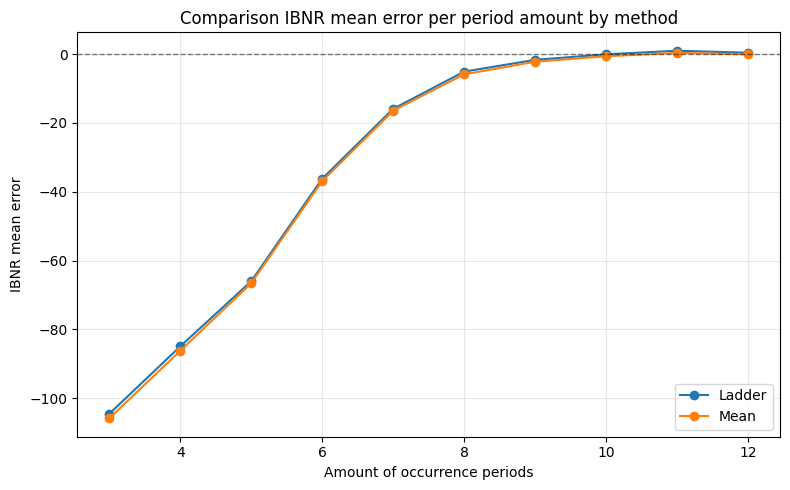

In [9]:
x_1 = np.asarray(occurrences, dtype=float)
y_ladder_1 = np.zeros_like(occurrences, dtype=float)
y_mean_1 = np.zeros_like(occurrences, dtype=float)

for occurrence_periods in occurrences:
    y_ladder_1[occurrence_periods - 3] = all_summaries_1[occurrence_periods]['mean_total_bias'][0]
    y_mean_1[occurrence_periods - 3] = all_summaries_1[occurrence_periods]['mean_total_bias'][1]

plt.figure(figsize=(8, 5))
plt.plot(x_1, y_ladder_1, marker='o', label='Ladder')
plt.plot(x_1, y_mean_1, marker='o', label='Mean')
plt.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)

plt.xlabel('Amount of occurrence periods')
plt.ylabel('IBNR mean error')
plt.title('Comparison IBNR mean error per period amount by method')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(
    os.path.join(out_dir_1, "comparison_ibnr_mean_by_method_1.png"),
    dpi=300,
    bbox_inches='tight'
)
plt.close(fig)

shutil.make_archive(out_dir_1, 'zip', out_dir_1)
files.download(f"{out_dir_1}.zip")

In [10]:
# from table 2.2 in Greg Taylor's Loss Reserving: An Actuarial Perspective

real_data_2 = np.asarray([
    [368, 191, 28, 8, 6, 5, 3, 1, 0],
    [393, 151, 25, 6, 4, 5, 4, 1, 2],
    [517, 185, 29, 17, 11, 10, 8, 1, 0],
    [578, 254, 49, 22, 17, 6, 3, 0, 1],
    [622, 206, 39, 16, 3, 7, 0, 1, 0],
    [660, 243, 28, 12, 12, 4, 4, 1, 0],
    [666, 234, 53, 10, 8, 4, 6, 1, 0],
    [573, 266, 62, 12, 5, 7, 6, 5, 1],
    [582, 281, 32, 27, 12, 13, 6, 2, 1]
], dtype=float)

mean_2, std_2, reporting_pattern_2, reporting_pattern_spread_2 = proc_real_data(real_data_2)

sampler_kwargs_2 = {"loc": mean_2, "scale": std_2}

all_results_2, all_summaries_2 = {}, {}
for occurrence_periods in occurrences:
    results, summary = monte_carlo_ibnr_count_exp(
        occurrence_periods=occurrence_periods,
        reporting_pattern=reporting_pattern_2,
        reporting_pattern_spread=reporting_pattern_spread_2,
        lambda_sampler=normal_lambda_sampler,
        sampler_kwargs=sampler_kwargs_2
    )
    all_results_2[occurrence_periods] = results
    all_summaries_2[occurrence_periods] = summary

In [11]:
out_dir_2 = "plots_2"
os.makedirs(out_dir_2, exist_ok=True)

for occurrence_periods in occurrences:
    results = all_results_2[occurrence_periods]
    results_ladder = results[results["method"] == "ladder_equal"]
    results_mean = results[results["method"] == "mean_equal"]

    fig, ax = plt.subplots(figsize=(8,4))
    ax.hist([results_ladder["ibnr_error_total"], results_mean["ibnr_error_total"]], bins=100, label=["chain ladder", "mean"])
    ax.axvline(0.0, color="green", linestyle="--", linewidth = 2, label="Perfect estimate")
    ax.axvline(results_ladder["ibnr_error_total"].mean(), color="blue", linestyle="--", linewidth = 2, label="Chain ladder mean")
    ax.axvline(results_mean["ibnr_error_total"].mean(), color="orange", linestyle="--", linewidth = 2, label="Mean mean")
    ax.set_title(f"Distribution of IBNR total error -- {occurrence_periods} periods")
    ax.set_xlabel("Error in number of IBNR claims")
    ax.set_ylabel("Number of scenarios")
    ax.legend()
    fig.tight_layout()

    fig.savefig(
        os.path.join(out_dir_2, f"ibnr_total_error_histogram_2_{occurrence_periods}_occurrence_periods.png"),
        dpi=300,
        bbox_inches='tight'
    )
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(8,4))
    ax.hist([results_ladder['est_ibnr_total'], results_mean['est_ibnr_total'], results_ladder['true_ibnr_total']], bins=100, label=["chain ladder", "mean", "true"])
    ax.axvline(results_ladder['est_ibnr_total'].mean(), color="blue", linestyle="--", linewidth = 2, label="Chain ladder mean")
    ax.axvline(results_ladder['est_ibnr_total'].mean(), color="orange", linestyle="--", linewidth = 2, label="Mean mean")
    ax.axvline(results_ladder['true_ibnr_total'].mean(), color="green", linestyle="--", linewidth = 2, label="True mean")
    ax.set_title(f"Total number of IBNR claims -- {occurrence_periods} periods")
    ax.set_xlabel("Number of IBNR claims")
    ax.set_ylabel("Number of scenarios")
    ax.legend()
    fig.tight_layout()

    fig.savefig(
        os.path.join(out_dir_2, f"total_number_of_ibnr_claims_2_{occurrence_periods}_occurrence_periods.png"),
        dpi=300,
        bbox_inches='tight'
    )
    plt.close(fig)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

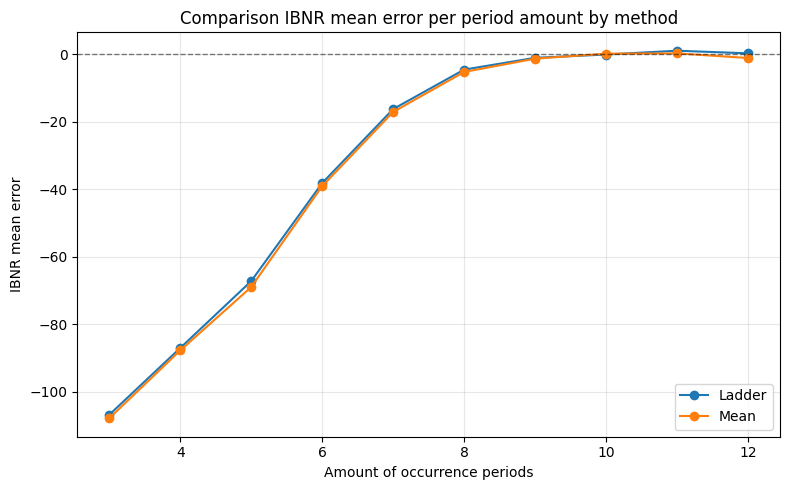

In [12]:
x_2 = np.asarray(occurrences, dtype=float)
y_ladder_2 = np.zeros_like(occurrences, dtype=float)
y_mean_2 = np.zeros_like(occurrences, dtype=float)

for occurrence_periods in occurrences:
    y_ladder_2[occurrence_periods - 3] = all_summaries_2[occurrence_periods]['mean_total_bias'][0]
    y_mean_2[occurrence_periods - 3] = all_summaries_2[occurrence_periods]['mean_total_bias'][1]

plt.figure(figsize=(8, 5))
plt.plot(x_2, y_ladder_2, marker='o', label='Ladder')
plt.plot(x_2, y_mean_2, marker='o', label='Mean')
plt.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)

plt.xlabel('Amount of occurrence periods')
plt.ylabel('IBNR mean error')
plt.title('Comparison IBNR mean error per period amount by method')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(
    os.path.join(out_dir_2, "comparison_ibnr_mean_by_method_2.png"),
    dpi=300,
    bbox_inches='tight'
)
plt.close(fig)

shutil.make_archive(out_dir_2, 'zip', out_dir_2)
files.download(f"{out_dir_2}.zip")